In [1]:
import os
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

import scanpy as sc
import palantir

import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import PINN
from PINN import reader

# identify detached / weird cells

In [4]:
ad = sc.read_h5ad("data/ery_mk.h5ad")
ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [5]:
train_DS = reader.TwoTimpepoint_AnnDS(
                            AnnData=ad, 
                            timepoint_idx=None, 
                            n_dimension = None,
                            cellstate_key= 'DM_EigenVectors_multiscaled',  #'DM_EigenVector'
                            log_transform=False,
                            norm_time = True,
                            deltax_key = 'Delta_DM',
                            kde_kws = {"bw_method": 0.5},
                            batchsize= 300)

Computing density :
`density_funs` not specified, use gaussian kde


In [40]:
train_DS.T_b

array([ 1.        ,  2.33333333,  4.        ,  9.        , 16.33333333,
       25.33333333, 37.33333333, 53.66666667, 89.66666667])

prediction of shape (9, 22740)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_u\nmin:0.e+00\nmax:1.00e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_u\nmin:0.e+00\nmax:5.75e-04'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_u\nmin:0.e+00\nmax:6.98e-04'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_u\nmin:0.e+00\nmax:1.93e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_u\nmin:0.e+00\nmax:2.47e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_u\nmin:1.23e-11\nmax:7.33e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_u\nmin:1.39e-28\nmax:1.09e-02'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_u\nmin:2.17e-28\nmax:3.67e-03'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_u\nmin:4.15e-08\nmax:3.35e-02'}, xlabel='UMAP1', ylabel='UMAP2'>],
       dtype=object))

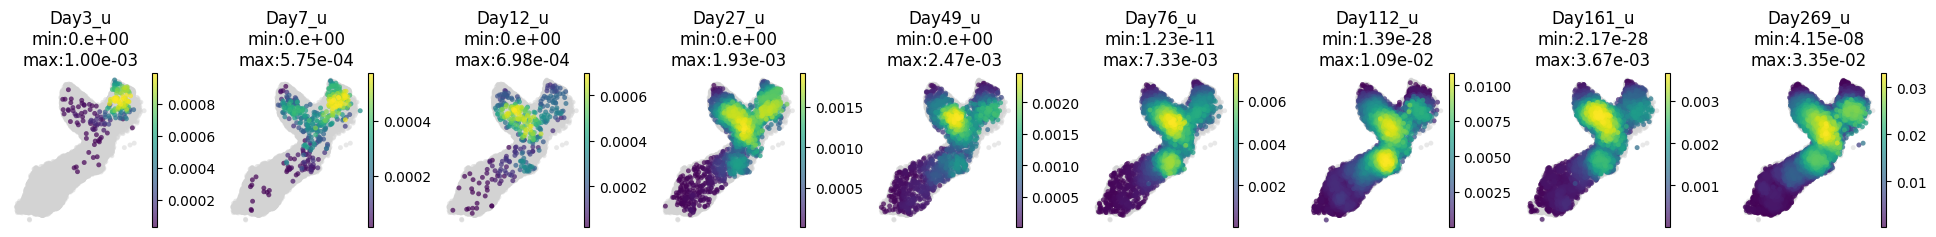

In [22]:
PINN.pl.params_in_umap(ad, train_DS.u_b, param='u')

prediction of shape (9, 22740)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_log u\nmin:-2.30e+01\nmax:-6.91e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_log u\nmin:-2.30e+01\nmax:-7.46e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_log u\nmin:-2.30e+01\nmax:-7.27e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_log u\nmin:-2.30e+01\nmax:-6.25e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_log u\nmin:-2.30e+01\nmax:-6.00e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_log u\nmin:-2.29e+01\nmax:-4.92e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_log u\nmin:-2.30e+01\nmax:-4.52e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_log u\nmin:-2.30e+01\nmax:-5.61e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day269_log u\nmin:-1.7e+01\nmax:-3.4e+00'

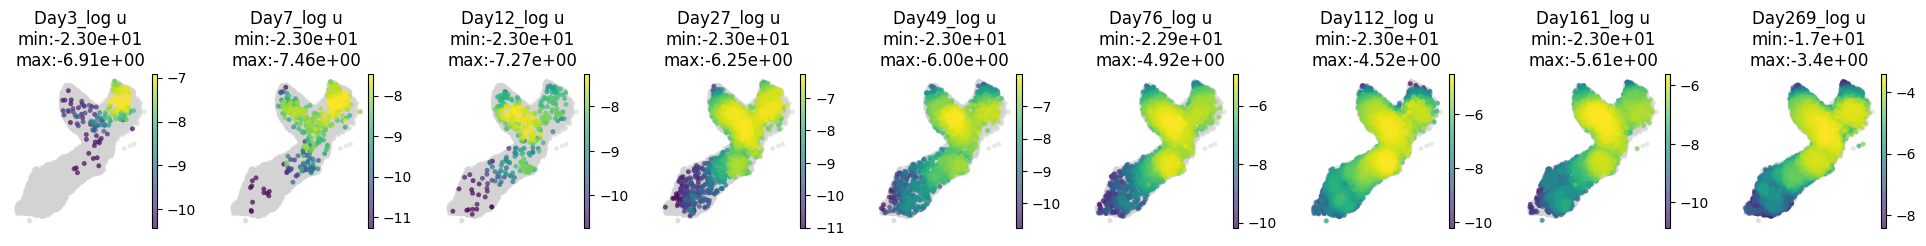

In [23]:
PINN.pl.params_in_umap(ad, np.log(train_DS.u_b+1e-10), param='log u')

# mellon

In [6]:
import mellon 

In [ ]:
X = ad.obsm['DM_EigenVectors_multiscaled']
X_times = ad.obs['timepoint_tx_days'].astype(int).apply(lambda x: np.log(x/3))
ls_time_estimate = 1.5 * np.mean(np.diff(np.log(ad.uns['pop']['t'])))


In [22]:
ad.uns['pop']['t']

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [36]:
t_est = mellon.TimeSensitiveDensityEstimator(d=2, ls_time=ls_time_estimate, ls_factor=3)
# Fit the estimator to the data
t_est.fit(X, X_times)
# t_est.predict.to_json(f"data/ery_mk_mellon_timecontinuous_predictor.json") 

[2025-07-22 20:20:35,432] [INFO    ] Explicitly provided d=2, setting d_method to 'manual'.
[2025-07-22 20:20:35,437] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (22,740) and rank = 1.0.
[2025-07-22 20:20:35,438] [INFO    ] Computing nearest neighbor distances within time points.
[2025-07-22 20:20:37,961] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=1.4415419135995151) * Matern52(active_dims=-1, ls=0.8430185795500742)).
[2025-07-22 20:20:37,966] [INFO    ] Computing 5,000 landmarks with k-means clustering (random_state=42).
[2025-07-22 20:20:56,576] [INFO    ] Using rank 5,000 covariance representation.
[2025-07-22 20:20:58,490] [INFO    ] Running inference using L-BFGS-B.
[2025-07-22 20:21:18,011] [INFO    ] Computing predictive function.


Parameter,Value
Jitter,1e-06
Mean (μ),-7.135236608276826
Length Scale (ls),1.4415419135995151
Length Scale Factor,3.0
Time Length Scale (ls_time),0.8430185795500742
Time Length Scale Factor,1.0
Intrinsic Dimensionality (d),2.0
Nearest Neighbor Distances,"<array 22,740, dtype=float64>"


In [37]:
predictor = t_est.predict

In [38]:
log_u = []
for t in ad.uns['pop']['t']:
    log_u.append( predictor(X, np.log(t/3)))

prediction of shape (9, 22740)


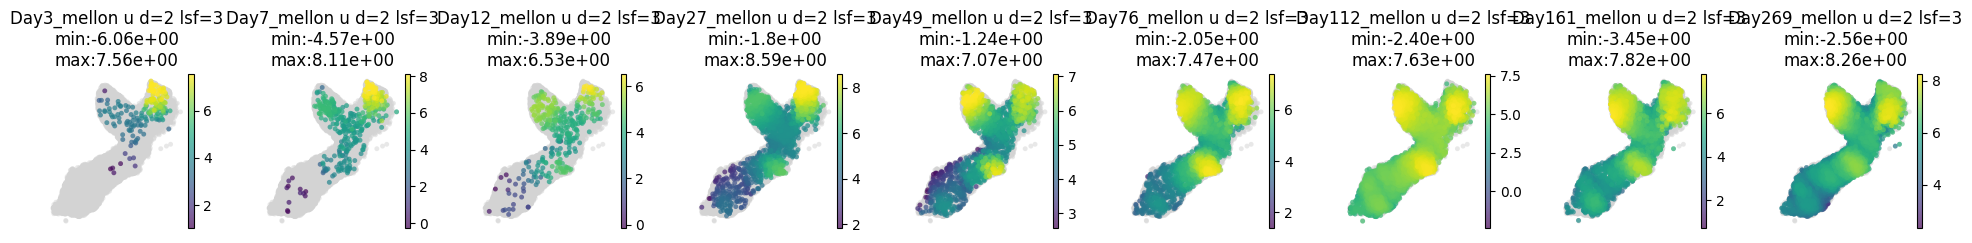

In [39]:
PINN.pl.params_in_umap(ad, np.stack(log_u), param='mellon u d=2 lsf=3'); # d=2 ls factor=3;

prediction of shape (9, 22740)


(<Figure size 2430x200 with 18 Axes>,
 array([<Axes: title={'center': 'Day3_mellon log u\nmin:-7.13e+00\nmax:-2.67e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day7_mellon log u\nmin:-7.1e+00\nmax:5.64e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day12_mellon log u\nmin:-7.04e+00\nmax:9.06e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day27_mellon log u\nmin:-6.71e+00\nmax:7.51e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day49_mellon log u\nmin:-6.35e+00\nmax:7.47e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day76_mellon log u\nmin:-6.19e+00\nmax:9.10e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day112_mellon log u\nmin:-6.02e+00\nmax:7.59e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'center': 'Day161_mellon log u\nmin:-5.81e+00\nmax:7.40e+00'}, xlabel='UMAP1', ylabel='UMAP2'>,
        <Axes: title={'cen

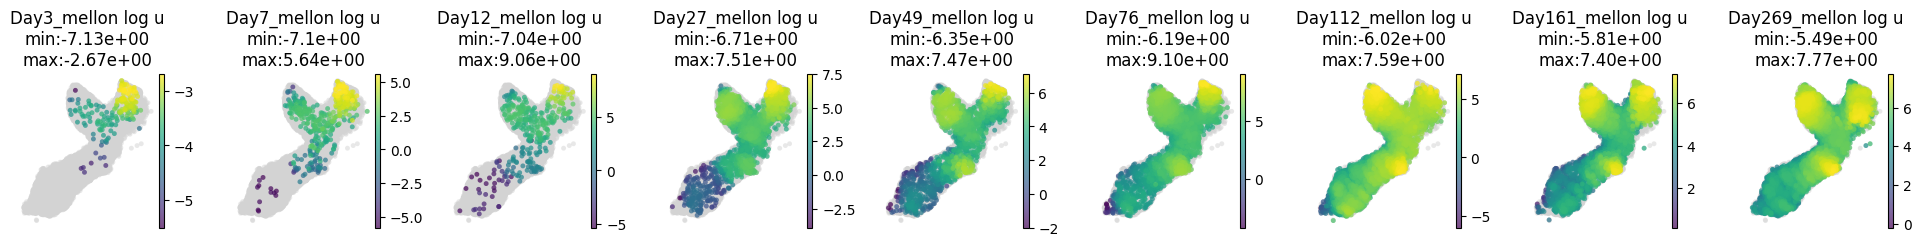

In [ ]:
# d=2 ls factor=1
PINN.pl.params_in_umap(ad, np.stack(log_u), param='mellon log u'); 